In [8]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
import sys
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# where WellClass and Ga[ codes are located
sys.path.append('../')

%matplotlib inline

In [10]:
from src.WellClass.libs2.models.well_model import WellModel
from src.WellClass.libs2.well_class   import WellProcessed
from src.WellClass.libs2.well_class   import Well
from src.WellClass.libs2.plotting.plot_sketch import plot_sketch

In [11]:
frigg_json = '../test_data/examples/frigg/25-1-10.json'

json_data = json.load(open(frigg_json))


my_model = WellModel(**json_data)

In [12]:
my_well = WellProcessed.from_json(frigg_json)

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='radius [m]', ylabel='depth [mMSL]'>)

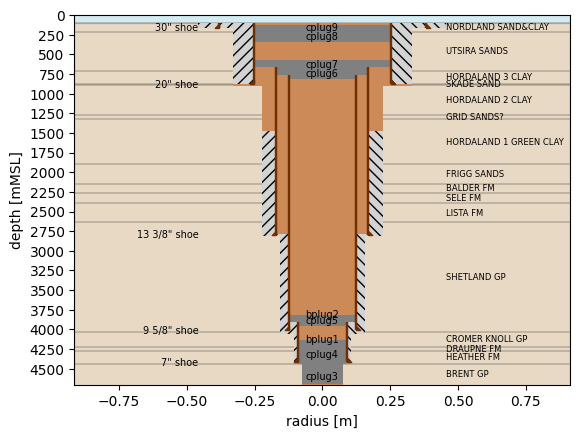

In [13]:
my_well.plot_sketch()

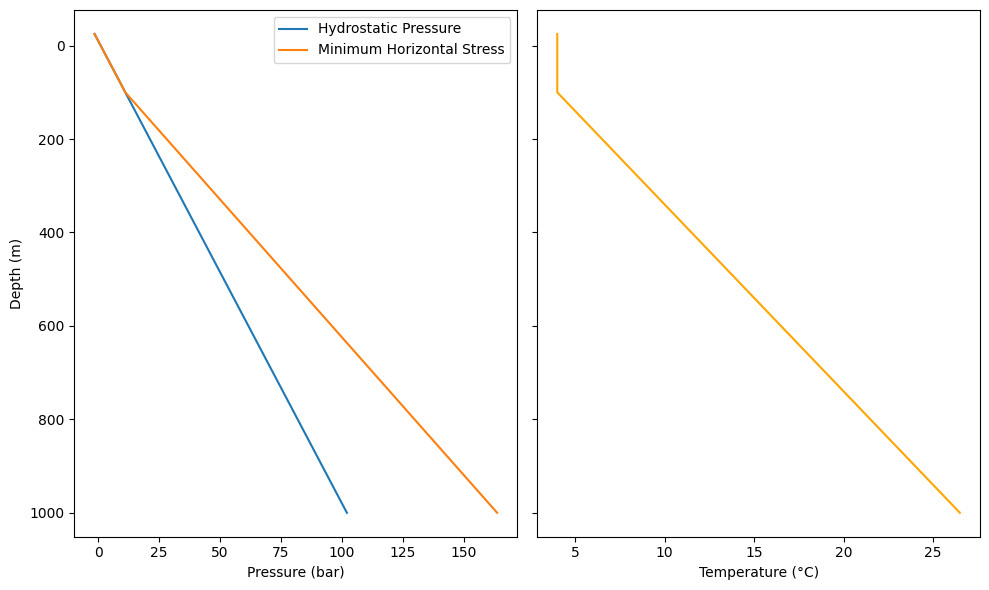

In [14]:
from src.WellClass.libs2.well_pressure import PressureTable


my_pressure_table = PressureTable(
    name='test',
    top_depth=-25,
    bottom_depth=1000,
    ground_elevation=100,
    ground_temperature=4,
    geothermal_gradient=25,
    )

fig, ax = plt.subplots(1, 2, sharey=True, figsize=(10, 6))

ax[0].plot(my_pressure_table.hydrostatic_pressure, my_pressure_table.depth, label='Hydrostatic Pressure')
ax[0].plot(my_pressure_table.min_horizontal_stress, my_pressure_table.depth, label='Minimum Horizontal Stress')
ax[0].set_xlabel('Pressure (bar)')
ax[0].set_ylabel('Depth (m)')
ax[0].invert_yaxis()
ax[0].legend()

ax[1].plot(my_pressure_table.temperature, my_pressure_table.depth, label='Temperature', color='orange')
ax[1].set_xlabel('Temperature (°C)')



fig.tight_layout()

/workspaces/WINC_OnePager/notebooks/../src/WellClass/libs2/well_pressure/pressure_utils.py:19: UserWarning: No Shmin data between seafloor depth (109) and minimum provided depth (111.18364). Extrapolating using hydrostatic pressure at seafloor.
  warnings.warn(


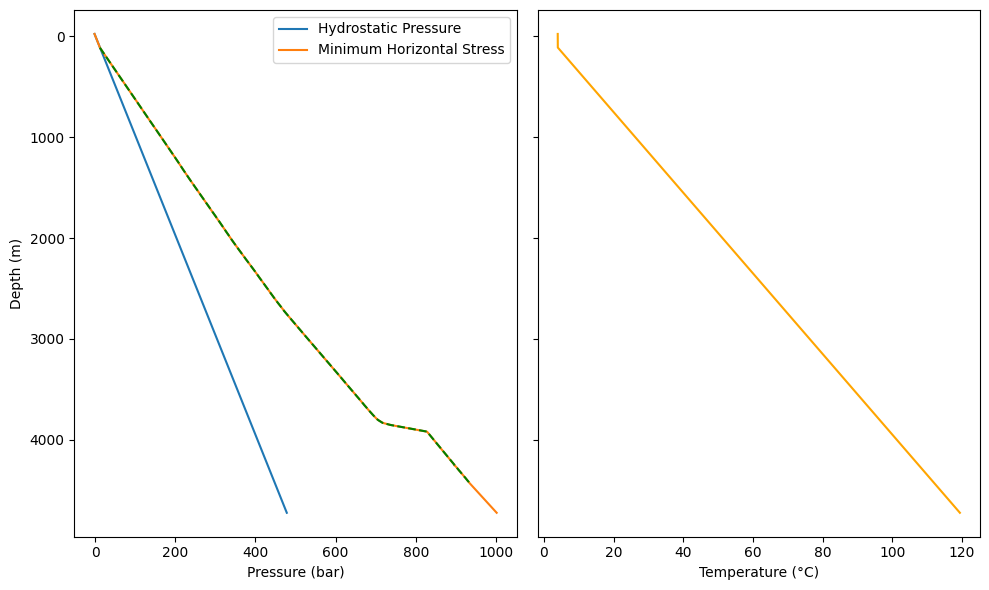

In [15]:
import json

with open("winc_payload.json") as f:
    json_data = json.load(f)

shmin_data = np.array(json_data["shMinOriginal"])

sf_depth_msl = json_data["waterDepth"]

td = max(json_data['depthAxis'])


from src.WellClass.libs2.well_pressure import PressureTable


my_pressure_table = PressureTable(
    name='test',
    top_depth=-25,
    bottom_depth=td,
    ground_elevation=sf_depth_msl,
    ground_temperature=4,
    geothermal_gradient=25,
    shmin_data=shmin_data.tolist()
    )

fig, ax = plt.subplots(1, 2, sharey=True, figsize=(10, 6))

ax[0].plot(my_pressure_table.hydrostatic_pressure, my_pressure_table.depth, label='Hydrostatic Pressure')
ax[0].plot(my_pressure_table.min_horizontal_stress, my_pressure_table.depth, label='Minimum Horizontal Stress')
ax[0].set_xlabel('Pressure (bar)')
ax[0].set_ylabel('Depth (m)')
ax[0].invert_yaxis()
ax[0].legend()

ax[1].plot(my_pressure_table.temperature, my_pressure_table.depth, label='Temperature', color='orange')
ax[1].set_xlabel('Temperature (°C)')

ax[0].plot(shmin_data[:, 1], shmin_data[:, 0], label='shmin data', color='green', linestyle='--' )

fig.tight_layout()

In [16]:
max(json_data['depthAxis'])

4724

In [17]:

table = PressureTable(
    name="test", top_depth=-25, bottom_depth=1000,
    ground_elevation=100, ground_temperature=4, geothermal_gradient=25,
)





In [19]:
table.add_scenario(name="CO2 base",  z_fluid_contact=500, p_delta=10, rho_fluid=400)
table.add_scenario(name="CO2 high",  z_fluid_contact=500, p_delta=30, rho_fluid=400)
table.add_scenario(name="hydrostatic", z_fluid_contact=500)

FluidPressure(table=PressureTable(name='test', top_depth=-25, bottom_depth=1000, ground_elevation=100, ground_temperature=4, geothermal_gradient=25, step=1.0, rho_brine=1030, shmin_gradient=0.1695, shmin_data=None, depth=array([ -25.,  -24.,  -23., ...,  998.,  999., 1000.], shape=(1026,)), temperature=array([ 4.   ,  4.   ,  4.   , ..., 26.45 , 26.475, 26.5  ], shape=(1026,)), hydrostatic_pressure=array([ -1.51196237,  -1.41095388,  -1.30994539, ..., 101.81972801,
       101.9207365 , 102.021745  ], shape=(1026,)), min_horizontal_stress=array([ -1.51196237,  -1.41095388,  -1.30994539, ..., 163.3250995 ,
       163.4945995 , 163.6640995 ], shape=(1026,)), scenarios=[FluidPressure(table=..., name='CO2 base', z_fluid_contact=500, p_fluid_contact=61.5174975, p_delta=10, z_resrv=None, p_resrv=None, rho_fluid=400, fluid_pressure=array([40.9235325, 40.9627591, 41.0019857, ..., 81.0523443, 81.0915709,
       81.1307975], shape=(1026,)), brine_pressure=array([  8.48803763,   8.58904612,   8.69

In [20]:
table.scenarios

[FluidPressure(table=PressureTable(name='test', top_depth=-25, bottom_depth=1000, ground_elevation=100, ground_temperature=4, geothermal_gradient=25, step=1.0, rho_brine=1030, shmin_gradient=0.1695, shmin_data=None, depth=array([ -25.,  -24.,  -23., ...,  998.,  999., 1000.], shape=(1026,)), temperature=array([ 4.   ,  4.   ,  4.   , ..., 26.45 , 26.475, 26.5  ], shape=(1026,)), hydrostatic_pressure=array([ -1.51196237,  -1.41095388,  -1.30994539, ..., 101.81972801,
        101.9207365 , 102.021745  ], shape=(1026,)), min_horizontal_stress=array([ -1.51196237,  -1.41095388,  -1.30994539, ..., 163.3250995 ,
        163.4945995 , 163.6640995 ], shape=(1026,)), scenarios=[..., FluidPressure(table=..., name='CO2 high', z_fluid_contact=500, p_fluid_contact=81.51749749999999, p_delta=30, z_resrv=None, p_resrv=None, rho_fluid=400, fluid_pressure=array([ 60.9235325,  60.9627591,  61.0019857, ..., 101.0523443,
        101.0915709, 101.1307975], shape=(1026,)), brine_pressure=array([ 28.48803763